# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-9: Algoritmo de Bernstein-Vazirani (Qiskit)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-9.  
Implementación equivalente en Qiskit del notebook Cirq `07_bernstein_vazirani.ipynb`.

### Relación con Deutsch-Jozsa

Bernstein-Vazirani puede verse como una extensión de Deutsch-Jozsa. Comparten el mismo circuito base (H → oráculo → H → medición), pero cambia el **tipo de pregunta**:

| Algoritmo | Pregunta al oráculo | Consultas clásicas | Consultas cuánticas |
|---|---|:---:|:---:|
| Deutsch-Jozsa | ¿La función es balanceada o constante? | $2^{n-1}+1$ | 1 |
| Bernstein-Vazirani | ¿Cuál es la cadena secreta $s$? | $n$ | 1 |

### Problema que resuelve

Existe una función desconocida $f_s: \{0,1\}^n \rightarrow \{0,1\}$ definida por una **cadena secreta** $s = s_0 s_1 \ldots s_{n-1}$:

$$f_s(x) = s \odot x = (s_0 x_0 + s_1 x_1 + \cdots + s_{n-1} x_{n-1}) \mod 2$$

**Clásicamente:** $n$ consultas — una por bit.  
**Cuánticamente:** **1 sola consulta** → medición directa de $s$.

### Pasos del algoritmo

| Paso | Acción | Estado resultante |
|---|---|---|
| 0 | Inicializar $n$ qubits de entrada + 1 qubit objetivo | $\vert 0\rangle^{\otimes n}\vert 0\rangle$ |
| 1 | H en cada qubit de entrada → superposición uniforme | $\frac{1}{\sqrt{2^n}} \sum_{x} \vert x\rangle \vert 0\rangle$ |
| 2 | X + H en qubit objetivo → $\vert -\rangle$ (phase kickback) | $\frac{1}{\sqrt{2^n}} \sum_{x} \vert x\rangle \vert -\rangle$ |
| 3 | Oracle $U_{f_s}$: CX(input$[i]$ → target) para cada $s_i = 1$ | $\frac{1}{\sqrt{2^n}} \sum_{x} (-1)^{s \odot x} \vert x\rangle \vert -\rangle$ |
| 4 | H en cada qubit de entrada → interferencia | Amplitud 1 solo en $\vert s\rangle$, cero en todos los demás |
| 5 | Medir qubits de entrada | Siempre se obtiene $\vert s\rangle$ con probabilidad 1 |

### Diferencias de API respecto al libro (Qiskit 1.0+)

| Libro (API antigua) | Este notebook (Qiskit ≥1.0) |
|---|---|
| `from qiskit import execute, Aer` | `from qiskit_aer import AerSimulator` |
| `Aer.get_backend('qasm_simulator')` | `AerSimulator()` |
| `execute(circuit, simulator, shots=n)` | `simulator.run(transpile(circuit, simulator), shots=n)` |

### Orden de bits en Qiskit

Qiskit devuelve el resultado como una cadena `c[n-1]...c[1]c[0]` — el bit más significativo primero, que es el **inverso** del orden en que se definieron los qubits. Al comparar con la cadena secreta original es necesario invertir la cadena resultado con `[::-1]`.

### Generación de la cadena secreta

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


def func_bit_pattern(num_qubits):
    """
    Genera aleatoriamente la cadena secreta s de num_qubits bits.
    Cada bit es 0 o 1 con igual probabilidad.
    """
    return [np.random.randint(0, 2) for _ in range(num_qubits)]

### Oráculo

El oráculo implementa $U_{f_s}\,\vert x\rangle\vert y\rangle = \vert x\rangle\vert y \oplus f_s(x)\rangle$.  
Para cada bit $s_i = 1$ aplica CX(input$[i]$ → target), acumulando $s \odot x$ en el qubit objetivo.  
Con el qubit objetivo en $\vert -\rangle$, esto produce el phase kickback $(-1)^{s \odot x}$ en los qubits de entrada.

In [2]:
def oracle(circuit, input_qubits, target_qubit, bit_pattern):
    """
    Aplica el oráculo de Bernstein-Vazirani.

    Para cada posición i donde bit_pattern[i] == 1, aplica
    CX(input[i] → target), codificando s·x en el qubit objetivo.
    """
    for i, bit in enumerate(bit_pattern):
        if bit == 1:
            circuit.cx(input_qubits[i], target_qubit)
    return circuit

### Algoritmo principal

In [3]:
def BV_algorithm(num_qubits, bit_pattern, shots=1000):
    """
    Implementa el algoritmo de Bernstein-Vazirani.

    num_qubits:  número de qubits de entrada (longitud de la cadena secreta)
    bit_pattern: cadena secreta s como lista de enteros 0/1
    shots:       repeticiones de la simulación

    Retorna: (circuit, counts)
    """
    input_qubits = list(range(num_qubits))  # q[0] ... q[n-1]
    target_qubit = num_qubits               # q[n]

    # n qubits de entrada + 1 qubit objetivo, n bits clásicos para medir la entrada
    circuit = QuantumCircuit(num_qubits + 1, num_qubits)

    # Paso 1: H en cada qubit de entrada → superposición uniforme
    for q in input_qubits:
        circuit.h(q)

    # Paso 2: preparar qubit objetivo en |-⟩ = H|1⟩
    circuit.x(target_qubit)
    circuit.h(target_qubit)

    circuit.barrier()

    # Paso 3: oráculo — codifica la cadena secreta s en la fase de los qubits de entrada
    circuit = oracle(circuit, input_qubits, target_qubit, bit_pattern)

    circuit.barrier()

    # Paso 4: H en cada qubit de entrada → interferencia constructiva solo en |s⟩
    for q in input_qubits:
        circuit.h(q)

    # Paso 5: medir qubits de entrada — el resultado debe ser exactamente s
    circuit.measure(input_qubits, list(range(num_qubits)))

    simulator = AerSimulator()
    counts = simulator.run(transpile(circuit, simulator), shots=shots).result().get_counts()

    return circuit, counts

---
## Ejecución con la cadena del libro: `s = 111011`

Usamos la misma cadena secreta del libro para reproducir su salida y verificar la implementación.

In [4]:
SECRET = [1, 1, 1, 0, 1, 1]  # cadena del libro: 111011
NUM_QUBITS = len(SECRET)

print(f"Cadena secreta (oráculo): {''.join(str(b) for b in SECRET)}")

circuit, counts = BV_algorithm(NUM_QUBITS, SECRET)
print(circuit.draw(output='text'))

Cadena secreta (oráculo): 111011
     ┌───┐      ░                           ░ ┌───┐┌─┐               
q_0: ┤ H ├──────░───■───────────────────────░─┤ H ├┤M├───────────────
     ├───┤      ░   │                       ░ ├───┤└╥┘┌─┐            
q_1: ┤ H ├──────░───┼────■──────────────────░─┤ H ├─╫─┤M├────────────
     ├───┤      ░   │    │                  ░ ├───┤ ║ └╥┘┌─┐         
q_2: ┤ H ├──────░───┼────┼────■─────────────░─┤ H ├─╫──╫─┤M├─────────
     ├───┤      ░   │    │    │             ░ ├───┤ ║  ║ └╥┘┌─┐      
q_3: ┤ H ├──────░───┼────┼────┼─────────────░─┤ H ├─╫──╫──╫─┤M├──────
     ├───┤      ░   │    │    │             ░ ├───┤ ║  ║  ║ └╥┘┌─┐   
q_4: ┤ H ├──────░───┼────┼────┼────■────────░─┤ H ├─╫──╫──╫──╫─┤M├───
     ├───┤      ░   │    │    │    │        ░ ├───┤ ║  ║  ║  ║ └╥┘┌─┐
q_5: ┤ H ├──────░───┼────┼────┼────┼────■───░─┤ H ├─╫──╫──╫──╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║  ║  ║  ║ └╥┘
q_6: ┤ X ├┤ H ├─░─┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├─░───────╫──╫─

### Visualización del circuito

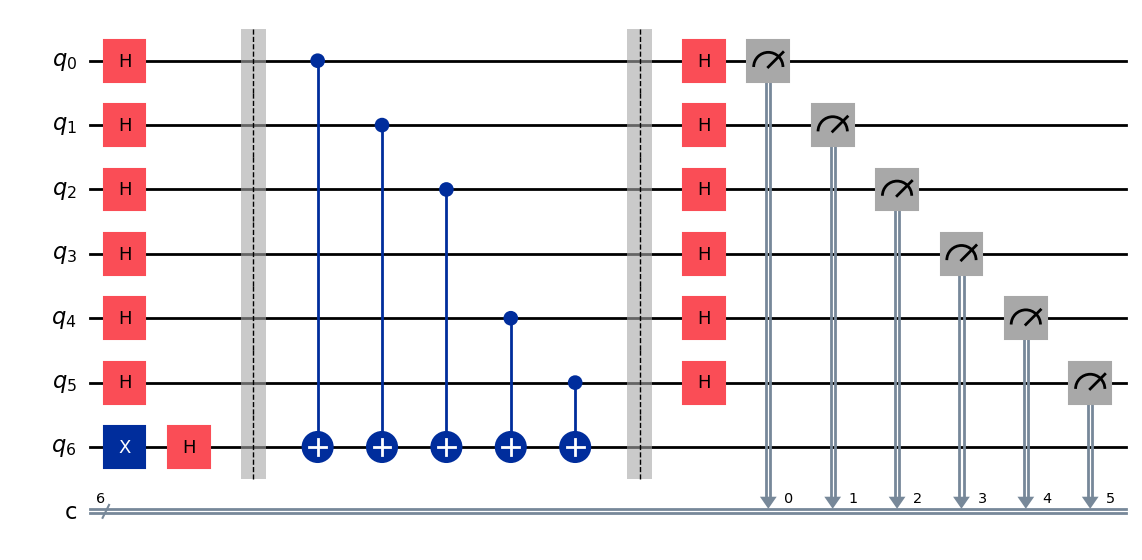

In [5]:
circuit.draw('mpl')

### Histograma de mediciones

La medición debe colapsar **siempre** al estado $\vert s\rangle$.

> **Nota sobre el orden de bits:** Qiskit devuelve la cadena en orden inverso (`c[n-1]...c[0]`).  
> Invertimos con `[::-1]` para comparar directamente con la cadena secreta original.

Cadena recuperada: 111011
Cadena secreta:    111011
Coinciden: True


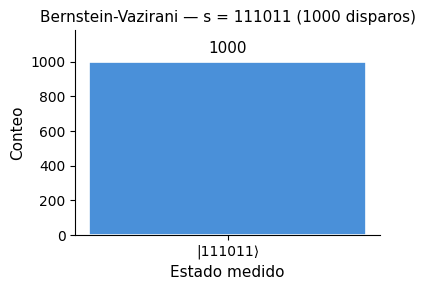

In [6]:
from qml_santanu.common.plot_utils import plot_counts

# Invertir la cadena resultado para que coincida con el orden de bit_pattern
counts_ordenados = {k[::-1]: v for k, v in counts.items()}

recuperada = list(counts_ordenados.keys())[0]
secreta    = ''.join(str(b) for b in SECRET)

print(f"Cadena recuperada: {recuperada}")
print(f"Cadena secreta:    {secreta}")
print(f"Coinciden: {recuperada == secreta}")

plot_counts(counts_ordenados, title=f'Bernstein-Vazirani — s = {secreta}')

**Interpretación:** las 1000 mediciones dan el mismo resultado — la cadena secreta $s$ completa. El algoritmo es **determinista**.

---
## Ejecución con cadena aleatoria

El algoritmo funciona para cualquier cadena. Generamos una aleatoria para confirmar que la recuperación es siempre perfecta.

Cadena secreta aleatoria: 011110
Cadena recuperada:        011110
Coinciden: True


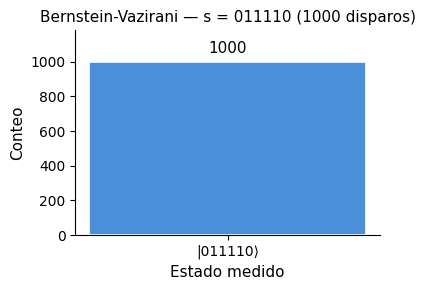

In [7]:
secret_random = func_bit_pattern(NUM_QUBITS)
secreta_r = ''.join(str(b) for b in secret_random)
print(f"Cadena secreta aleatoria: {secreta_r}")

_, counts_r = BV_algorithm(NUM_QUBITS, secret_random)
counts_r_ordenados = {k[::-1]: v for k, v in counts_r.items()}

recuperada_r = list(counts_r_ordenados.keys())[0]
print(f"Cadena recuperada:        {recuperada_r}")
print(f"Coinciden: {recuperada_r == secreta_r}")

plot_counts(counts_r_ordenados, title=f'Bernstein-Vazirani — s = {recuperada_r}')